# ========================================================
# IMPLEMENTAÇÃO DE UMA DEEP BELIEF NETWORK (DBN) NO MNIST
# Fiel à formulação de Gibbs Sampling e Contrastive Divergence (CD-1)
# ========================================================

In [ ]:
# Instalação e Carregamento de Dependências
# -----------------------------------------------------------------------------
# Installing R packages
# keras: loading mnist dataset
# -----------------------------------------------------------------------------
packages = c("keras3")
for(pkg in packages) {
  if(!(pkg %in% rownames(installed.packages()))) {
    cat("Installing: ", pkg, "\n")
    install.packages(pkg)
  }
}

Installing:  keras3 


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘RcppTOML’, ‘here’, ‘png’, ‘config’, ‘tfautograph’, ‘reticulate’, ‘tensorflow’, ‘tfruns’, ‘zeallot’, ‘dotty’




In [ ]:
# -----------------------------------------------------------------------------
# Loading packages
# -----------------------------------------------------------------------------
library("keras3")

In [ ]:
# Preparação dos Dados com Binarização
cat("Carregando dados MNIST...\n")
mnist <- dataset_mnist()

Carregando dados MNIST...


In [ ]:
cat("Binarizando dados MNIST...\n")

# Pega o número de imagens automaticamente (nrow)
n_imagens <- dim(mnist$train$x)[1]

# Faz o reshape dinâmico: (Total de imagens, 784)
x_train <- array_reshape(mnist$train$x, c(n_imagens, 784)) / 255 #normaliza values in [0,1]

# Transformando em vetor e aplicando o threshold de 0.5
x_train <- ifelse(x_train >= 0.5, 1, 0)

Binarizando dados MNIST...


In [ ]:
# Função de ativação Sigmóide (conforme derivação dos slides)
sigmoid <- function(x) { 1 / (1 + exp(-x)) }

In [ ]:
# ------------------------------------------------------------------------------
# FUNÇÃO DE TREINAMENTO RBM (Módulo fundamental da DBN)
# Implementa o Gibbs Sampling de Passo 1 (CD-1) de forma estocástica
# ------------------------------------------------------------------------------
train_rbm_layer <- function(input_data, n_hidden, epochs = 30, lr = 0.1) {
  n_visible <- ncol(input_data)
  n_samples <- nrow(input_data)

  # Inicialização dos parâmetros (Nomes dos slides: W, b, c)
  # W: Pesos | b: Bias das Escondidas | c: Bias das Visíveis
  W <- matrix(rnorm(n_visible * n_hidden, sd = 0.1), n_visible, n_hidden)
  b <- rep(0, n_hidden)
  c <- rep(0, n_visible)

  cat(sprintf("\nTreinando camada: %d visíveis -> %d escondidas\n", n_visible, n_hidden))
  flush.console()

  for (epoch in 1:epochs) {
    # v0 representa o dado real de entrada
    v0 <- input_data

    # --------------------------------------------------------------------------
    # GIBBS SAMPLING DE PASSO 1 (CD-1)
    # --------------------------------------------------------------------------

    # PASSO 1: FASE POSITIVA (Subida v -> h)
    # Calculamos p(h|v0)
    h0_prob <- sigmoid(v0 %*% W + matrix(b, nrow=n_samples, ncol=n_hidden, byrow=T))
    # Amostragem de Bernoulli: h0 binário {0, 1}
    h0_state <- (h0_prob > matrix(runif(n_samples * n_hidden), n_samples, n_hidden)) * 1

    # PASSO 2: FASE NEGATIVA (Descida h -> v) - Reconstrução
    # Aqui geramos o "x~" (x de Gibbs) mencionado nos slides
    # Calculamos p(v|h0)
    v1_prob <- sigmoid(h0_state %*% t(W) + matrix(c, nrow=n_samples, ncol=n_visible, byrow=T))
    # Amostragem de Bernoulli: v1 binário {0, 1} (Fiel à teoria de variáveis binárias)
    v1_state <- (v1_prob > matrix(runif(n_samples * n_visible), n_samples, n_visible)) * 1

    # PASSO 3: RE-PROJEÇÃO (Subida v1 -> h1)
    # Calculamos p(h|v1) para completar o passo de Gibbs
    h1_prob <- sigmoid(v1_state %*% W + matrix(b, nrow=n_samples, ncol=n_hidden, byrow=T))

    # --------------------------------------------------------------------------
    # ATUALIZAÇÃO DOS PESOS (Gradiente de Energia)
    # Delta W = lr * ( <v0, h0>_data - <v1_state, h1_prob>_model )
    # --------------------------------------------------------------------------
    W <- W + lr * (t(v0) %*% h0_prob - t(v1_state) %*% h1_prob) / n_samples

    # Atualização dos Biases (Deslocamento para reduzir a energia do sistema)
    b <- b + lr * colMeans(h0_prob - h1_prob)
    c <- c + lr * colMeans(v0 - v1_state)

    # Cálculo do Erro de Reconstrução (MSE entre dado real e x de Gibbs)
    error <- mean((v0 - v1_state)^2)
    cat(sprintf("Época %d - Erro Médio: %f\n", epoch, error))
    flush.console()
  }

  return(list(W = W, b = b, c = c))
}

In [ ]:
# ------------------------------------------------------------------------------
# CONSTRUÇÃO DA DBN (Treinamento Ganancioso Camada a Camada)
# ------------------------------------------------------------------------------

# Camada 1: Aprende traços básicos (784 -> 500)
rbm1 <- train_rbm_layer(x_train, n_hidden = 500, epochs = 30, lr = 0.1)

# Transformação: A entrada da Camada 2 é a ativação (h) da Camada 1
h1_input <- sigmoid(x_train %*% rbm1$W + matrix(rbm1$b, nrow(x_train), 500, byrow=T))
# Lembre-se: a RBM clássica assume que as unidades visíveis (v) são variáveis aleatórias de Bernoulli (0 ou 1)
h1_input_bin <- (h1_input > 0.5) * 1

# Camada 2: Aprende formas complexas (500 -> 250)
rbm2 <- train_rbm_layer(h1_input_bin, n_hidden = 250, epochs = 30, lr = 0.1)


Treinando camada: 784 visíveis -> 500 escondidas
Época 1 - Erro Médio: 0.475943
Época 2 - Erro Médio: 0.188359
Época 3 - Erro Médio: 0.162718
Época 4 - Erro Médio: 0.154567
Época 5 - Erro Médio: 0.150634
Época 6 - Erro Médio: 0.147119
Época 7 - Erro Médio: 0.144446
Época 8 - Erro Médio: 0.141691
Época 9 - Erro Médio: 0.139430
Época 10 - Erro Médio: 0.137142
Época 11 - Erro Médio: 0.135077
Época 12 - Erro Médio: 0.133004
Época 13 - Erro Médio: 0.131192
Época 14 - Erro Médio: 0.129169
Época 15 - Erro Médio: 0.127416
Época 16 - Erro Médio: 0.125775
Época 17 - Erro Médio: 0.123961
Época 18 - Erro Médio: 0.122436
Época 19 - Erro Médio: 0.120964
Época 20 - Erro Médio: 0.119478
Época 21 - Erro Médio: 0.118186
Época 22 - Erro Médio: 0.116869
Época 23 - Erro Médio: 0.115664
Época 24 - Erro Médio: 0.114567
Época 25 - Erro Médio: 0.113311
Época 26 - Erro Médio: 0.112285
Época 27 - Erro Médio: 0.111398
Época 28 - Erro Médio: 0.110348
Época 29 - Erro Médio: 0.109501
Época 30 - Erro Médio: 0.108599

In [ ]:
# ------------------------------------------------------------------------------
# APLICAÇÃO GENERATIVA:
# Gerando novos dígitos a partir de estados aleatórios no topo da rede
# ------------------------------------------------------------------------------

generate_mnist_dbn <- function(rbm_l1, rbm_l2, n_samples = 5, gibbs_steps = 500) {
  cat("\nGerando novos dígitos via amostragem de Gibbs no topo da DBN...\n")

  # Iniciamos com ativações aleatórias no topo (Camada 2)
  h2_state <- matrix(rnorm(n_samples * 250), n_samples, 250)
  h2_state <- (sigmoid(h2_state) > 0.5) * 1

  # Ciclo de Gibbs para estabilizar o conceito abstrato
  for (i in 1:gibbs_steps) {
    # h2 -> h1 (Descida)
    h1_prob <- sigmoid(h2_state %*% t(rbm_l2$W) + matrix(rbm_l2$c, n_samples, 500, byrow=T))
    h1_state <- (h1_prob > matrix(runif(length(h1_prob)), n_samples)) * 1

    # h1 -> h2 (Subida)
    h2_prob <- sigmoid(h1_state %*% rbm_l2$W + matrix(rbm_l2$b, n_samples, 250, byrow=T))
    h2_state <- (h2_prob > matrix(runif(length(h2_prob)), n_samples)) * 1
  }

  # Projeção final para os pixels (h1 -> v0)
  v_final_prob <- sigmoid(h1_state %*% t(rbm_l1$W) + matrix(rbm_l1$c, n_samples, 784, byrow=T))
  return(v_final_prob)
}


Gerando novos dígitos via amostragem de Gibbs no topo da DBN...


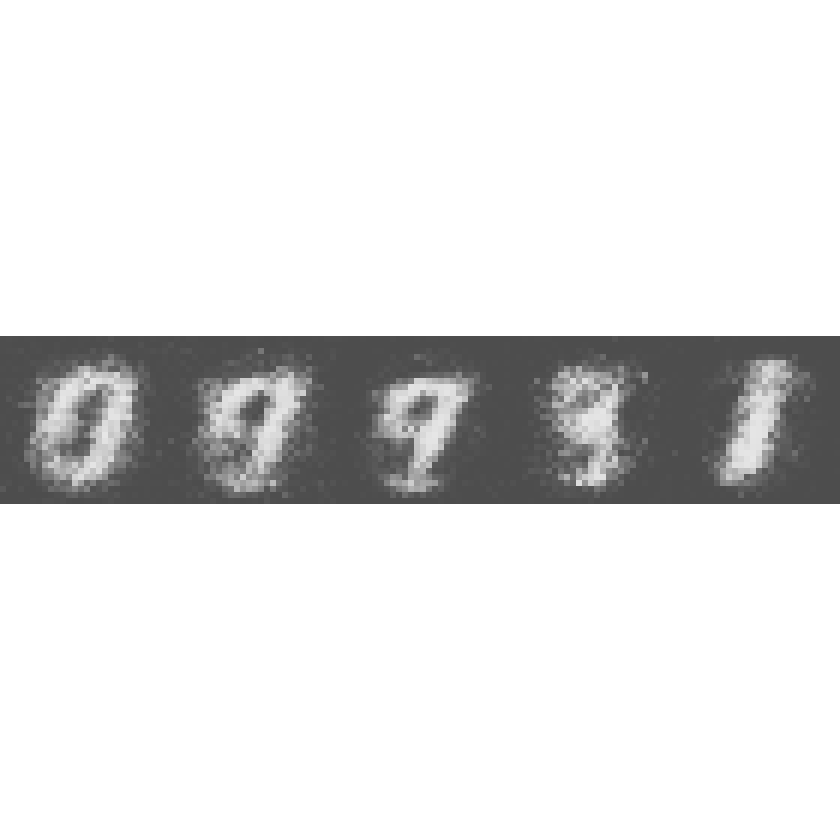

In [ ]:
# Gerar e Visualizar
num_amostras = 5
novos_digitos <- generate_mnist_dbn(rbm1, rbm2, n_samples = num_amostras, gibbs_steps = 20)

# Configura a janela para mostrar 5 imagens em uma linha
par(mfrow=c(1, num_amostras))

# Reduzimos as margens para 0 para maximizar o tamanho da imagem
par(mar=c(0, 0, 0, 0)) # Margens: baixo, esquerda, cima, direita. Todas 0.

for(i in 1:num_amostras) {
  # Remodela o vetor de 784 em uma matriz 28x28
  img_matrix <- matrix(novos_digitos[i,], 28, 28)

  # Plota a imagem corrigindo a orientação e a proporção
  # O segredo está aqui:
  # - [,28:1] rotaciona a matriz para ficar na orientação correta
  # - asp = 1 força a proporção quadrada (1:1), impedindo que fique esticada
  image(img_matrix[, 28:1],
        col = gray.colors(255),
        axes = FALSE,          # Remove os eixos (números nas bordas)
        asp = 1,               # <--- SOLUÇÃO PARA A DISTORÇÃO!
        #main = paste("Gerado", i))
  )
}